
 LOADING DATASET 
Dataset Path :
C:\Users\sapiyan\DL\Multiclass_classification\dataset\letter-recognition.data

 DATASET LOADED SUCCESSFULLY 

First 5 Rows:

  letter  x-box  y-box  width  height  onpix  x-bar  y-bar  x2bar  y2bar  \
0      T      2      8      3       5      1      8     13      0      6   
1      I      5     12      3       7      2     10      5      5      4   
2      D      4     11      6       8      6     10      6      2      6   
3      N      7     11      6       6      3      5      9      4      6   
4      G      2      1      3       1      1      8      6      6      6   

   xybar  x2ybr  xy2br  x-ege  xegvy  y-ege  yegvx  
0      6     10      8      0      8      0      8  
1     13      3      9      2      8      4     10  
2     10      3      7      3      7      3      9  
3      4      4     10      6     10      2      8  
4      6      5      9      1      7      5     10  

 LABEL ENCODING COMPLETED 

Classes:

['A' 'B' 'C' 'D' 'E' 'F' 'G

C:\Users\sapiyan\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.2852 - loss: 2.4539 - val_accuracy: 0.7194 - val_loss: 0.9214
Epoch 2/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6834 - loss: 1.0058 - val_accuracy: 0.8000 - val_loss: 0.6700
Epoch 3/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7629 - loss: 0.7595 - val_accuracy: 0.8350 - val_loss: 0.5432
Epoch 4/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7851 - loss: 0.6678 - val_accuracy: 0.8425 - val_loss: 0.4740
Epoch 5/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8071 - loss: 0.5915 - val_accuracy: 0.8819 - val_loss: 0.4001
Epoch 6/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8271 - loss: 0.5397 - val_accuracy: 0.8869 - val_loss: 0.3668
Epoch 7/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8443 - loss: 0.4832 - val_accuracy: 0.9025 - val_loss: 0.3267
Epoch 8/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8489 - loss: 0.4467 - val_accuracy: 0.9081

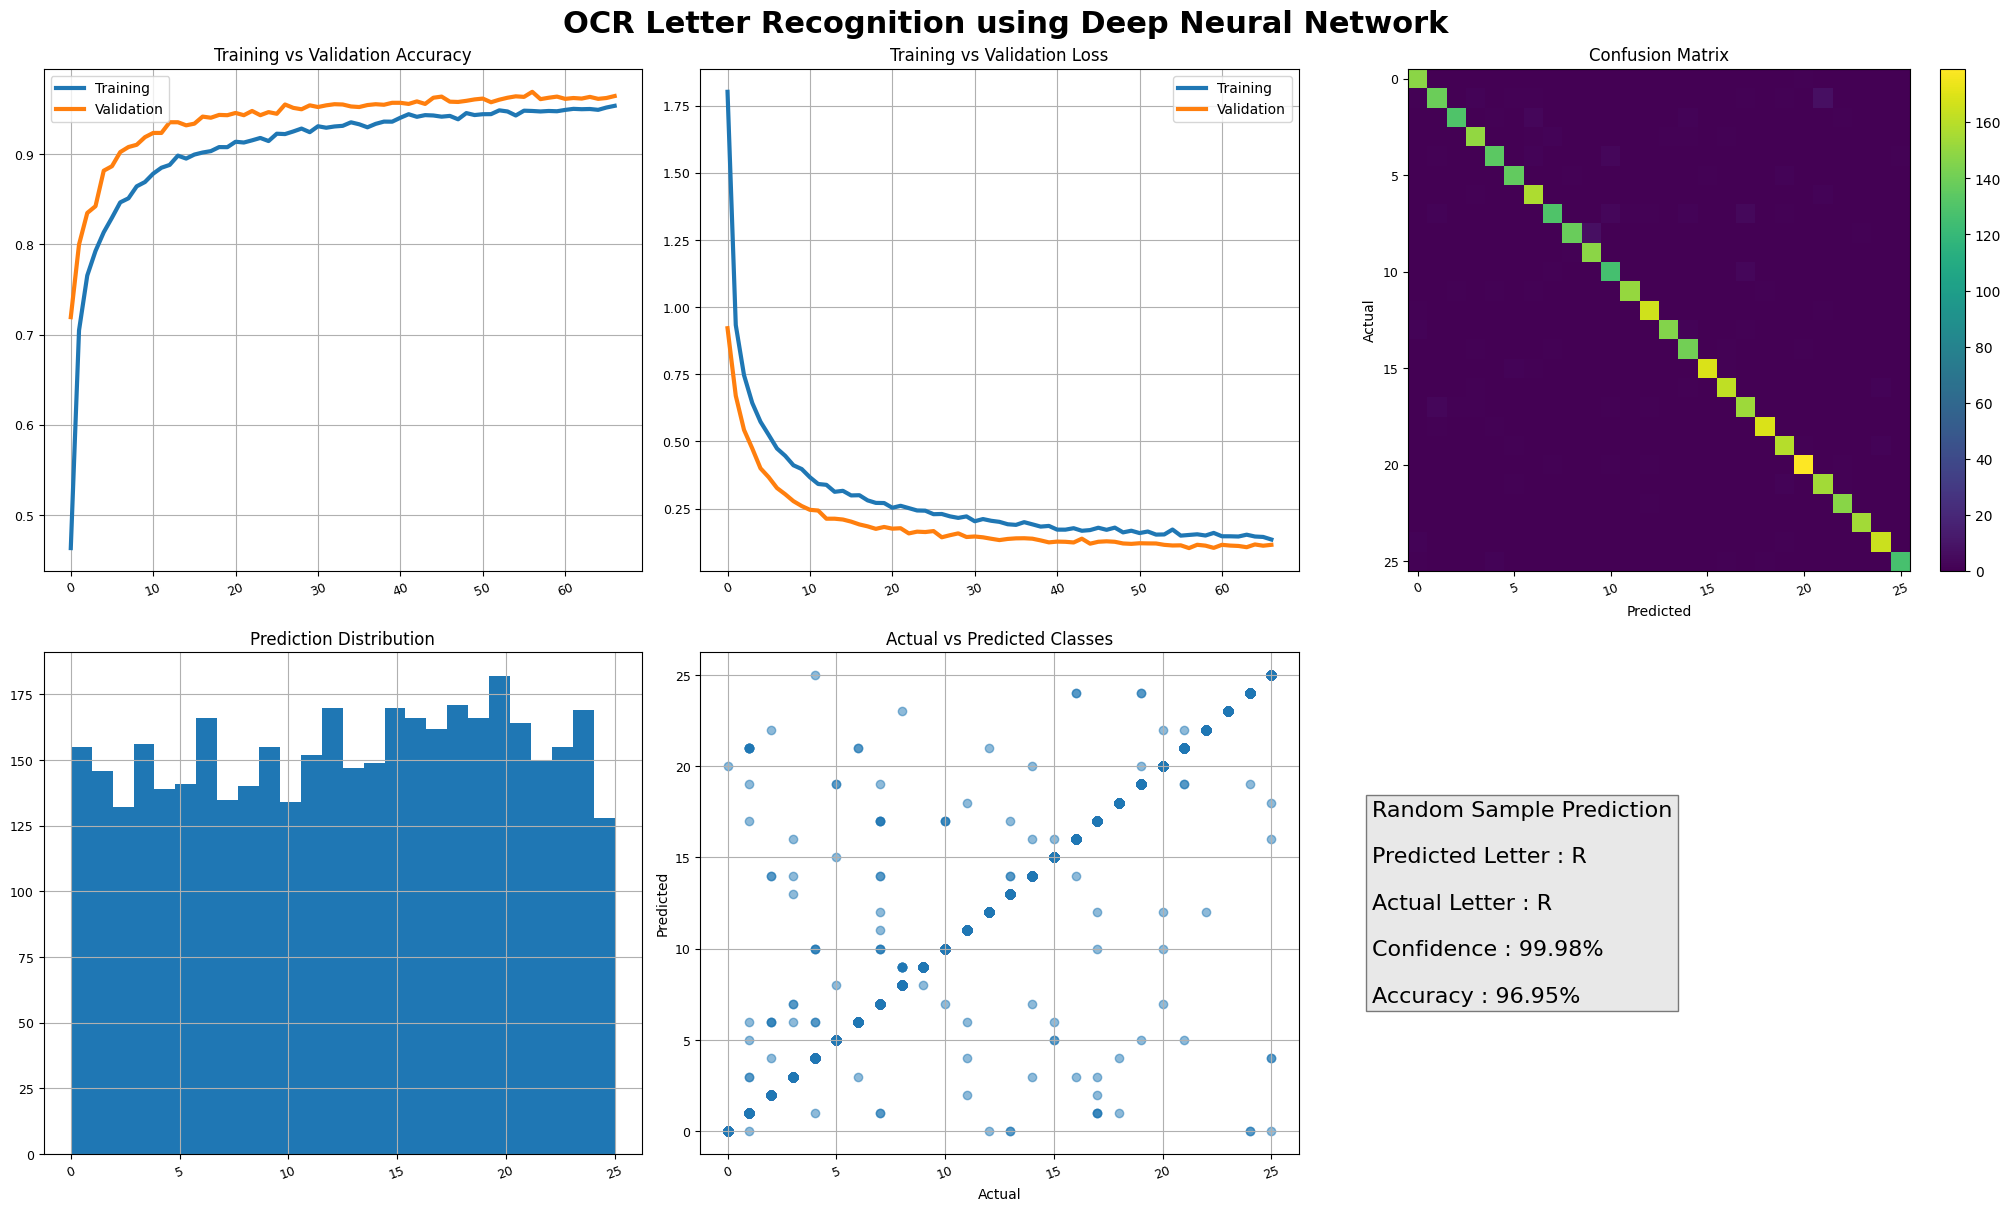


 FINAL ACCURACY 
Accuracy Score : 96.95 %

 MODEL SAVED SUCCESSFULLY 

 PROGRAM EXECUTED SUCCESSFULLY 


In [1]:
# =========================================================
# OCR Letter Recognition using Deep Neural Network
# FULL FINAL UPDATED CODE
# JUPYTER NOTEBOOK VERSION
# =========================================================

# =========================================================
# 1. IMPORT LIBRARIES
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import random

from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

# =========================================================
# 2. DATASET PATH
# =========================================================

dataset_path = r"C:\Users\sapiyan\DL\Multiclass_classification\dataset\letter-recognition.data"

print("\n====================================")
print(" LOADING DATASET ")
print("====================================")

print("Dataset Path :")
print(dataset_path)

# =========================================================
# 3. COLUMN NAMES
# =========================================================

columns = [

    'letter',

    'x-box',
    'y-box',
    'width',
    'height',

    'onpix',

    'x-bar',
    'y-bar',

    'x2bar',
    'y2bar',

    'xybar',

    'x2ybr',
    'xy2br',

    'x-ege',
    'xegvy',

    'y-ege',
    'yegvx'
]

# =========================================================
# 4. LOAD DATASET
# =========================================================

data = pd.read_csv(

    dataset_path,

    header=None,

    names=columns
)

print("\n====================================")
print(" DATASET LOADED SUCCESSFULLY ")
print("====================================")

print("\nFirst 5 Rows:\n")
print(data.head())

# =========================================================
# 5. FEATURES AND TARGET
# =========================================================

X = data.drop(
    'letter',
    axis=1
)

y = data['letter']

# =========================================================
# 6. LABEL ENCODING
# =========================================================

encoder = LabelEncoder()

y = encoder.fit_transform(y)

print("\n====================================")
print(" LABEL ENCODING COMPLETED ")
print("====================================")

print("\nClasses:\n")
print(encoder.classes_)

# =========================================================
# 7. FEATURE SCALING
# =========================================================

scaler = StandardScaler()

X = scaler.fit_transform(X)

print("\nFeature Scaling Completed")

# Standardization:
# z = (x - mean) / std

# =========================================================
# 8. TRAIN TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42
)

print("\n====================================")
print(" DATASET SPLIT COMPLETED ")
print("====================================")

print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

# =========================================================
# 9. BUILD DNN MODEL
# =========================================================

model = keras.Sequential([

    # -----------------------------------------------------
    # INPUT LAYER
    # -----------------------------------------------------

    layers.Dense(

        256,

        activation='relu',

        input_shape=(X_train.shape[1],)
    ),

    layers.Dropout(0.3),

    # -----------------------------------------------------
    # HIDDEN LAYER 1
    # -----------------------------------------------------

    layers.Dense(

        128,

        activation='relu'
    ),

    layers.Dropout(0.3),

    # -----------------------------------------------------
    # HIDDEN LAYER 2
    # -----------------------------------------------------

    layers.Dense(

        64,

        activation='relu'
    ),

    # -----------------------------------------------------
    # HIDDEN LAYER 3
    # -----------------------------------------------------

    layers.Dense(

        32,

        activation='relu'
    ),

    # -----------------------------------------------------
    # OUTPUT LAYER
    # -----------------------------------------------------

    layers.Dense(

        26,

        activation='softmax'
    )
])

# =========================================================
# 10. COMPILE MODEL
# =========================================================

model.compile(

    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']
)

print("\n====================================")
print(" MODEL COMPILED SUCCESSFULLY ")
print("====================================")

# =========================================================
# 11. EARLY STOPPING
# =========================================================

early_stop = keras.callbacks.EarlyStopping(

    monitor='val_loss',

    patience=10,

    restore_best_weights=True
)

# =========================================================
# 12. TRAIN MODEL
# =========================================================

print("\n====================================")
print(" MODEL TRAINING STARTED ")
print("====================================")

history = model.fit(

    X_train,
    y_train,

    validation_split=0.2,

    epochs=100,

    batch_size=32,

    callbacks=[early_stop],

    verbose=1
)

# =========================================================
# 13. EVALUATE MODEL
# =========================================================

loss, accuracy = model.evaluate(

    X_test,
    y_test,

    verbose=0
)

print("\n====================================")
print(" MODEL EVALUATION ")
print("====================================")

print("Test Loss     :", round(loss, 4))
print("Test Accuracy :", round(accuracy * 100, 2), "%")

# =========================================================
# 14. PREDICTIONS
# =========================================================

predictions = model.predict(
    X_test,
    verbose=0
)

predicted_classes = np.argmax(
    predictions,
    axis=1
)

# =========================================================
# 15. CLASSIFICATION REPORT
# =========================================================

print("\n====================================")
print(" CLASSIFICATION REPORT ")
print("====================================")

print(

    classification_report(

        y_test,

        predicted_classes,

        target_names=encoder.classes_
    )
)

# =========================================================
# 16. CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(

    y_test,

    predicted_classes
)

# =========================================================
# 17. RANDOM SAMPLE PREDICTION
# =========================================================

random_index = random.randint(
    0,
    len(X_test)-1
)

sample = X_test[random_index].reshape(1, -1)

prediction = model.predict(
    sample,
    verbose=0
)

predicted_class = np.argmax(prediction)

predicted_letter = encoder.inverse_transform(
    [predicted_class]
)

actual_letter = encoder.inverse_transform(
    [y_test[random_index]]
)

confidence = np.max(prediction) * 100

# =========================================================
# 18. CREATE ALL OUTPUTS TOGETHER
# =========================================================

fig, axes = plt.subplots(

    2,
    3,

    figsize=(20, 12),

    constrained_layout=True
)

# =========================================================
# MAIN TITLE
# =========================================================

fig.suptitle(

    "OCR Letter Recognition using Deep Neural Network",

    fontsize=22,

    fontweight='bold'
)

# =========================================================
# GRAPH 1 : ACCURACY GRAPH
# =========================================================

axes[0,0].plot(

    history.history['accuracy'],

    linewidth=3
)

axes[0,0].plot(

    history.history['val_accuracy'],

    linewidth=3
)

axes[0,0].set_title(
    "Training vs Validation Accuracy"
)

axes[0,0].legend([
    "Training",
    "Validation"
])

axes[0,0].grid(True)

# =========================================================
# GRAPH 2 : LOSS GRAPH
# =========================================================

axes[0,1].plot(

    history.history['loss'],

    linewidth=3
)

axes[0,1].plot(

    history.history['val_loss'],

    linewidth=3
)

axes[0,1].set_title(
    "Training vs Validation Loss"
)

axes[0,1].legend([
    "Training",
    "Validation"
])

axes[0,1].grid(True)

# =========================================================
# GRAPH 3 : CONFUSION MATRIX
# =========================================================

im = axes[0,2].imshow(cm)

axes[0,2].set_title(
    "Confusion Matrix"
)

axes[0,2].set_xlabel("Predicted")
axes[0,2].set_ylabel("Actual")

fig.colorbar(
    im,
    ax=axes[0,2]
)

# =========================================================
# GRAPH 4 : PREDICTION DISTRIBUTION
# =========================================================

axes[1,0].hist(

    predicted_classes,

    bins=26
)

axes[1,0].set_title(
    "Prediction Distribution"
)

axes[1,0].grid(True)

# =========================================================
# GRAPH 5 : REGRESSION STYLE GRAPH
# =========================================================

axes[1,1].scatter(

    y_test,

    predicted_classes,

    alpha=0.5
)

axes[1,1].set_title(
    "Actual vs Predicted Classes"
)

axes[1,1].set_xlabel("Actual")
axes[1,1].set_ylabel("Predicted")

axes[1,1].grid(True)

# =========================================================
# GRAPH 6 : RANDOM SAMPLE PREDICTION
# =========================================================

axes[1,2].axis("off")

prediction_text = (

    f"Random Sample Prediction\n\n"

    f"Predicted Letter : {predicted_letter[0]}\n\n"

    f"Actual Letter : {actual_letter[0]}\n\n"

    f"Confidence : {confidence:.2f}%\n\n"

    f"Accuracy : {accuracy*100:.2f}%"
)

axes[1,2].text(

    0.1,
    0.5,

    prediction_text,

    fontsize=16,

    verticalalignment='center',

    bbox=dict(
        facecolor='lightgray',
        alpha=0.5
    )
)

# =========================================================
# FIX OVERLAPPING
# =========================================================

for ax in axes.flat:

    ax.tick_params(

        axis='x',

        rotation=20,

        labelsize=9
    )

    ax.tick_params(

        axis='y',

        labelsize=9
    )

# =========================================================
# SHOW EVERYTHING
# =========================================================

plt.show()

# =========================================================
# 19. FINAL ACCURACY
# =========================================================

final_accuracy = accuracy_score(

    y_test,

    predicted_classes
)

print("\n====================================")
print(" FINAL ACCURACY ")
print("====================================")

print(
    "Accuracy Score :",
    round(final_accuracy * 100, 2),
    "%"
)

# =========================================================
# 20. SAVE MODEL
# =========================================================

model.save(
    "ocr_letter_dnn_model.h5"
)

print("\n====================================")
print(" MODEL SAVED SUCCESSFULLY ")
print("====================================")

# =========================================================
# 21. PROGRAM FINISHED
# =========================================================

print("\n====================================")
print(" PROGRAM EXECUTED SUCCESSFULLY ")
print("====================================")